# 📈 Momentum Cross-Sectionnel — Recherche
Objectif : valider la rentabilité d'une stratégie Long/Short basée sur le
momentum relatif entre cryptos, **après frais**, avant de coder le bot live.

**Concept** : chaque semaine, on classe l'univers par performance sur les
4 dernières semaines. On va Long sur les meilleurs, Short sur les pires.
Rebalancement hebdomadaire, poids égaux.

**Complémentarité avec StatArb** : le momentum parie sur la continuation,
StatArb sur le retour à la moyenne — logiquement actif en régime TRENDING.

In [1]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1. Univers — perpetuals liquides

In [2]:
UNIVERSE = [
    'BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT', 'XRP/USDT',
    'DOGE/USDT', 'ADA/USDT', 'AVAX/USDT', 'LINK/USDT', 'DOT/USDT',
    'MATIC/USDT', 'LTC/USDT', 'UNI/USDT', 'AAVE/USDT', 'ARB/USDT',
    'OP/USDT', 'SUI/USDT', 'NEAR/USDT', 'APT/USDT', 'FIL/USDT',
    'ATOM/USDT', 'ETC/USDT', 'ICP/USDT', 'HBAR/USDT', 'RENDER/USDT',
]
print(f'Univers : {len(UNIVERSE)} symboles')

Univers : 25 symboles


## 2. Données — daily close, 1 an

In [3]:
exchange = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'future'}})

def fetch_daily_close(symbol, days=400):
    since = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)
    try:
        ohlcv = exchange.fetch_ohlcv(symbol, '1d', since=since, limit=1000)
        if not ohlcv:
            return None
        df = pd.DataFrame(ohlcv, columns=['timestamp','open','high','low','close','volume'])
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df = df.set_index('timestamp')[['close']]
        df.columns = [symbol]
        return df
    except Exception as e:
        print(f'  ⚠️ {symbol}: {e}')
        return None

print('📥 Téléchargement (peut prendre 1-2 min)...')
prices = {}
for sym in UNIVERSE:
    df = fetch_daily_close(sym)
    if df is not None and len(df) > 60:
        prices[sym] = df
        print(f'  ✅ {sym:<12} — {len(df)} jours')
    else:
        print(f'  ❌ {sym}')

price_df = pd.concat(prices.values(), axis=1).dropna()
print(f'\n✅ Matrice de prix : {price_df.shape[0]} jours × {price_df.shape[1]} symboles')
print(f'   Période : {price_df.index[0].date()} → {price_df.index[-1].date()}')

📥 Téléchargement (peut prendre 1-2 min)...
  ✅ BTC/USDT     — 400 jours
  ✅ ETH/USDT     — 400 jours
  ✅ SOL/USDT     — 400 jours
  ✅ BNB/USDT     — 400 jours
  ✅ XRP/USDT     — 400 jours
  ✅ DOGE/USDT    — 400 jours
  ✅ ADA/USDT     — 400 jours
  ✅ AVAX/USDT    — 400 jours
  ✅ LINK/USDT    — 400 jours
  ✅ DOT/USDT     — 400 jours
  ⚠️ MATIC/USDT: binance does not have market symbol MATIC/USDT
  ❌ MATIC/USDT
  ✅ LTC/USDT     — 400 jours
  ✅ UNI/USDT     — 400 jours
  ✅ AAVE/USDT    — 400 jours
  ✅ ARB/USDT     — 400 jours
  ✅ OP/USDT      — 400 jours
  ✅ SUI/USDT     — 400 jours
  ✅ NEAR/USDT    — 400 jours
  ✅ APT/USDT     — 400 jours
  ✅ FIL/USDT     — 400 jours
  ✅ ATOM/USDT    — 400 jours
  ✅ ETC/USDT     — 400 jours
  ✅ ICP/USDT     — 400 jours
  ✅ HBAR/USDT    — 400 jours
  ✅ RENDER/USDT  — 400 jours

✅ Matrice de prix : 400 jours × 24 symboles
   Période : 2025-05-28 → 2026-07-01


## 3. Paramètres de la stratégie

In [4]:
LOOKBACK_DAYS   = 28    # Fenêtre de formation du momentum (4 semaines)
SKIP_DAYS       = 1     # Skip le jour le plus récent (évite reversal court-terme)
REBALANCE_DAYS  = 7     # Rebalancement hebdomadaire
N_LONG          = 5     # Nombre d'actifs en Long (meilleurs momentum)
N_SHORT         = 5     # Nombre d'actifs en Short (pires momentum)

# Frais perpetual Binance (standard, sans BNB)
TAKER_FEE       = 0.0005   # 0.05% par ordre
ROUND_TRIP_FEE  = TAKER_FEE * 2   # Entrée + sortie par position

print(f'Lookback     : {LOOKBACK_DAYS}j (momentum de formation)')
print(f'Rebalance    : tous les {REBALANCE_DAYS}j')
print(f'Portefeuille : {N_LONG} Long / {N_SHORT} Short')
print(f'Frais RT     : {ROUND_TRIP_FEE*100:.3f}% par position par rebalancement')

Lookback     : 28j (momentum de formation)
Rebalance    : tous les 7j
Portefeuille : 5 Long / 5 Short
Frais RT     : 0.100% par position par rebalancement


## 4. Backtest — construction du portefeuille à chaque rebalancement

In [5]:
returns = price_df.pct_change().fillna(0)

rebalance_dates = price_df.index[LOOKBACK_DAYS::REBALANCE_DAYS]

portfolio_returns = []
portfolio_dates   = []
holdings_log      = []

for i, date in enumerate(rebalance_dates[:-1]):
    next_date = rebalance_dates[i + 1]

    # Momentum = performance sur LOOKBACK_DAYS, en excluant les SKIP_DAYS les plus récents
    end_idx   = price_df.index.get_loc(date) - SKIP_DAYS
    start_idx = end_idx - LOOKBACK_DAYS
    if start_idx < 0:
        continue

    momentum = (price_df.iloc[end_idx] / price_df.iloc[start_idx] - 1).sort_values(ascending=False)

    longs  = momentum.head(N_LONG).index.tolist()
    shorts = momentum.tail(N_SHORT).index.tolist()

    holdings_log.append({'date': date, 'longs': longs, 'shorts': shorts})

    # Rendement de la période suivante pour ce portefeuille (equal-weight)
    period_returns = returns.loc[date:next_date].iloc[1:]  # Exclut le jour du rebalancement lui-même
    if period_returns.empty:
        continue

    long_ret  = period_returns[longs].mean(axis=1)
    short_ret = -period_returns[shorts].mean(axis=1)  # Short = rendement inversé

    # Portefeuille market-neutral : 50% Long, 50% Short
    port_ret = (long_ret + short_ret) / 2

    # Frais appliqués au premier jour de la période (rebalancement)
    port_ret.iloc[0] -= ROUND_TRIP_FEE

    portfolio_returns.append(port_ret)

portfolio_returns = pd.concat(portfolio_returns)
print(f'✅ Backtest terminé : {len(rebalance_dates)-1} rebalancements simulés')
print(f'   Période effective : {portfolio_returns.index[0].date()} → {portfolio_returns.index[-1].date()}')

✅ Backtest terminé : 53 rebalancements simulés
   Période effective : 2025-07-03 → 2026-07-01


## 5. Résultats — courbe de capital et métriques

📊 RÉSULTATS DU BACKTEST (net de frais)
  Rendement total       : -26.28%
  Rendement annualisé   : -26.41%
  Volatilité annualisée : 20.64%
  Sharpe Ratio          : -1.28
  Max Drawdown          : -35.81%
  % jours positifs      : 50.5%
  Frais totaux payés    : 53 rebalancements × 0.100%


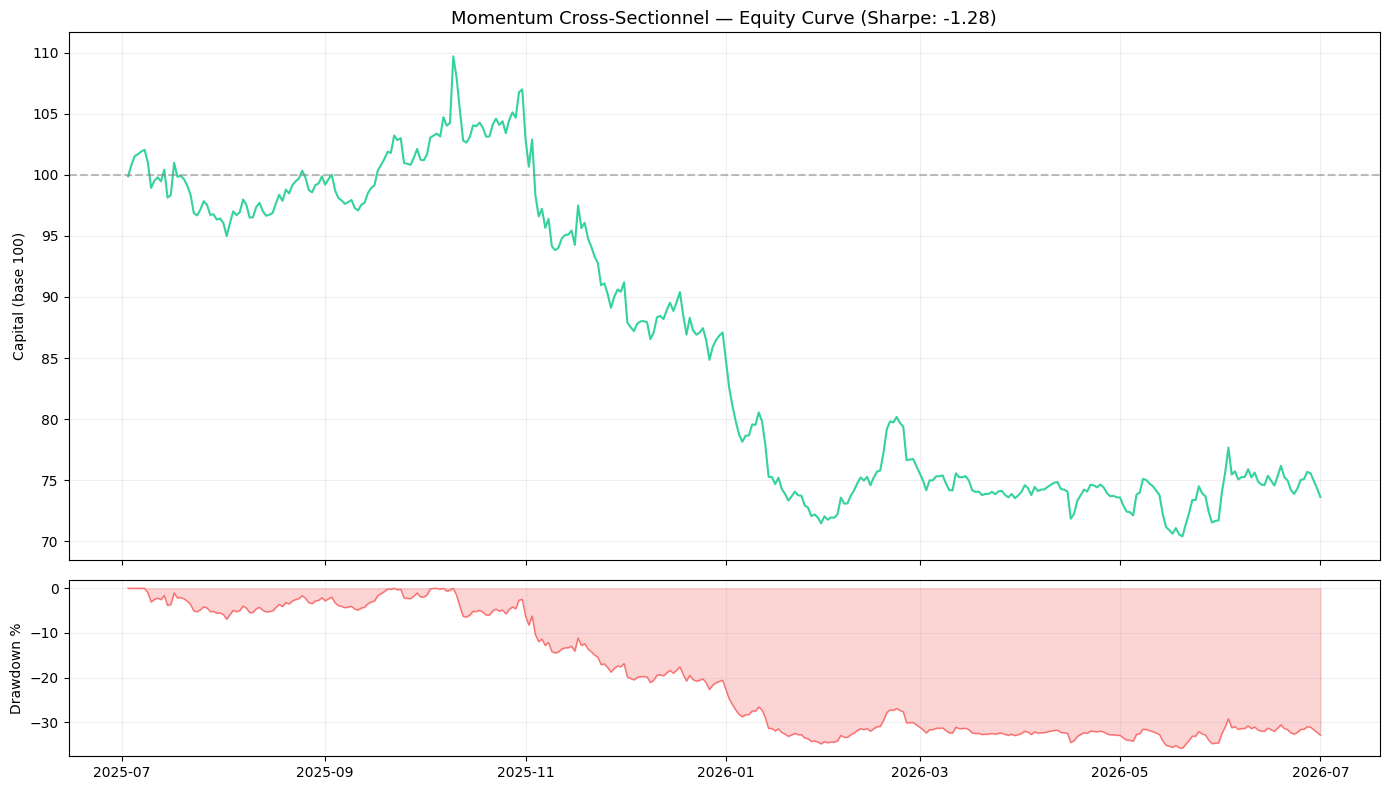

In [6]:
equity_curve = (1 + portfolio_returns).cumprod() * 100

total_return   = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
n_days         = (portfolio_returns.index[-1] - portfolio_returns.index[0]).days
annualized_ret = ((1 + total_return/100) ** (365/n_days) - 1) * 100 if n_days > 0 else 0

daily_vol      = portfolio_returns.std()
annualized_vol = daily_vol * np.sqrt(365) * 100
sharpe         = (annualized_ret / annualized_vol) if annualized_vol > 0 else 0

cummax   = equity_curve.cummax()
drawdown = (equity_curve - cummax) / cummax * 100
max_dd   = drawdown.min()

win_days = (portfolio_returns > 0).mean() * 100

print('📊 RÉSULTATS DU BACKTEST (net de frais)')
print('='*50)
print(f'  Rendement total       : {total_return:+.2f}%')
print(f'  Rendement annualisé   : {annualized_ret:+.2f}%')
print(f'  Volatilité annualisée : {annualized_vol:.2f}%')
print(f'  Sharpe Ratio          : {sharpe:.2f}')
print(f'  Max Drawdown          : {max_dd:.2f}%')
print(f'  % jours positifs      : {win_days:.1f}%')
print(f'  Frais totaux payés    : {len(rebalance_dates)-1} rebalancements × {ROUND_TRIP_FEE*100:.3f}%')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(equity_curve.index, equity_curve, color='#34d399', linewidth=1.5)
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax1.set_title(f'Momentum Cross-Sectionnel — Equity Curve (Sharpe: {sharpe:.2f})', fontsize=13)
ax1.set_ylabel('Capital (base 100)')
ax1.grid(alpha=0.2)

ax2.fill_between(drawdown.index, drawdown, 0, color='#f87171', alpha=0.3)
ax2.plot(drawdown.index, drawdown, color='#f87171', linewidth=1)
ax2.set_ylabel('Drawdown %')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Décomposition Long vs Short

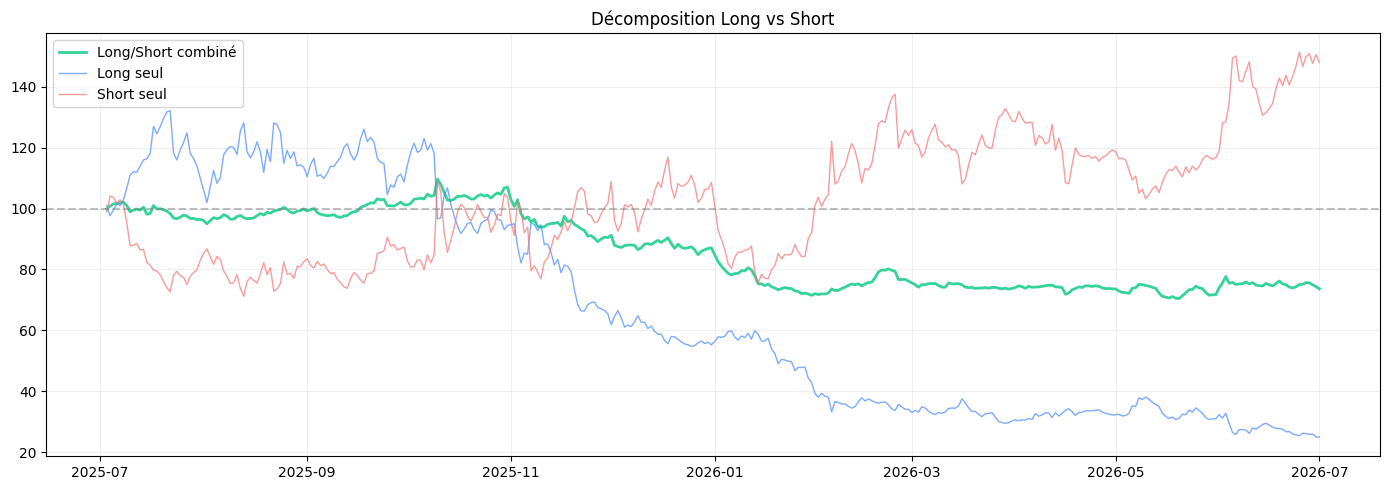

Rendement Long seul  : -75.28%
Rendement Short seul : +49.52%

💡 Si le Short seul est très négatif, c'est probablement le bull run —
   le momentum "perdant" a quand même souvent monté, juste moins que le reste.


In [7]:
# Est-ce que le Long ou le Short contribue le plus à la performance ?
long_only_returns  = []
short_only_returns = []

for i, date in enumerate(rebalance_dates[:-1]):
    next_date = rebalance_dates[i + 1]
    end_idx   = price_df.index.get_loc(date) - SKIP_DAYS
    start_idx = end_idx - LOOKBACK_DAYS
    if start_idx < 0:
        continue
    momentum = (price_df.iloc[end_idx] / price_df.iloc[start_idx] - 1).sort_values(ascending=False)
    longs  = momentum.head(N_LONG).index.tolist()
    shorts = momentum.tail(N_SHORT).index.tolist()
    period_returns = returns.loc[date:next_date].iloc[1:]
    if period_returns.empty:
        continue
    long_only_returns.append(period_returns[longs].mean(axis=1))
    short_only_returns.append(-period_returns[shorts].mean(axis=1))

long_only_returns  = pd.concat(long_only_returns)
short_only_returns = pd.concat(short_only_returns)

long_equity  = (1 + long_only_returns).cumprod() * 100
short_equity = (1 + short_only_returns).cumprod() * 100

plt.figure(figsize=(14, 5))
plt.plot(equity_curve.index, equity_curve, label='Long/Short combiné', color='#34d399', linewidth=2)
plt.plot(long_equity.index, long_equity, label='Long seul', color='#4488ff', linewidth=1, alpha=0.7)
plt.plot(short_equity.index, short_equity, label='Short seul', color='#f87171', linewidth=1, alpha=0.7)
plt.axhline(100, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Décomposition Long vs Short')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Rendement Long seul  : {(long_equity.iloc[-1]/long_equity.iloc[0]-1)*100:+.2f}%")
print(f"Rendement Short seul : {(short_equity.iloc[-1]/short_equity.iloc[0]-1)*100:+.2f}%")
print('\n💡 Si le Short seul est très négatif, c\'est probablement le bull run —')
print('   le momentum "perdant" a quand même souvent monté, juste moins que le reste.')

## 7. Sensibilité — quel N_LONG/N_SHORT et LOOKBACK optimaux ?

In [8]:
def run_backtest(lookback, n_assets, skip=1, rebalance=7):
    rebal_dates = price_df.index[lookback::rebalance]
    all_rets = []
    for i, date in enumerate(rebal_dates[:-1]):
        next_date = rebal_dates[i+1]
        end_idx = price_df.index.get_loc(date) - skip
        start_idx = end_idx - lookback
        if start_idx < 0:
            continue
        mom = (price_df.iloc[end_idx] / price_df.iloc[start_idx] - 1).sort_values(ascending=False)
        longs, shorts = mom.head(n_assets).index.tolist(), mom.tail(n_assets).index.tolist()
        pr = returns.loc[date:next_date].iloc[1:]
        if pr.empty:
            continue
        r = (pr[longs].mean(axis=1) - pr[shorts].mean(axis=1)) / 2
        r.iloc[0] -= ROUND_TRIP_FEE
        all_rets.append(r)
    if not all_rets:
        return None, None
    all_rets = pd.concat(all_rets)
    tot_ret = (1+all_rets).prod() - 1
    vol = all_rets.std() * np.sqrt(365)
    sharpe = (tot_ret / ((len(all_rets)/365))) / vol if vol > 0 else 0
    return tot_ret * 100, sharpe

print('🔬 Grid search — Lookback × N_assets')
print('='*60)
results_grid = []
for lb in [14, 21, 28, 35]:
    for n in [3, 5, 7]:
        tot, sh = run_backtest(lb, n)
        if tot is not None:
            results_grid.append({'lookback': lb, 'n_assets': n, 'total_return_pct': round(tot,2), 'sharpe': round(sh,2)})
            print(f"  Lookback={lb:>3}j | N={n} | Return: {tot:>+7.2f}% | Sharpe: {sh:.2f}")

df_grid = pd.DataFrame(results_grid).sort_values('sharpe', ascending=False)
print(f'\n🏆 Meilleure config : Lookback={df_grid.iloc[0]["lookback"]}j, N={df_grid.iloc[0]["n_assets"]}, Sharpe={df_grid.iloc[0]["sharpe"]}')

🔬 Grid search — Lookback × N_assets
  Lookback= 14j | N=3 | Return:  -30.72% | Sharpe: -1.14
  Lookback= 14j | N=5 | Return:  -24.53% | Sharpe: -1.18
  Lookback= 14j | N=7 | Return:  -24.48% | Sharpe: -1.38
  Lookback= 21j | N=3 | Return:  -13.07% | Sharpe: -0.52
  Lookback= 21j | N=5 | Return:  -12.09% | Sharpe: -0.58
  Lookback= 21j | N=7 | Return:   -0.25% | Sharpe: -0.01
  Lookback= 28j | N=3 | Return:  -28.20% | Sharpe: -1.10
  Lookback= 28j | N=5 | Return:  -26.38% | Sharpe: -1.28
  Lookback= 28j | N=7 | Return:  -26.67% | Sharpe: -1.40
  Lookback= 35j | N=3 | Return:  -37.81% | Sharpe: -1.51
  Lookback= 35j | N=5 | Return:  -35.13% | Sharpe: -1.76
  Lookback= 35j | N=7 | Return:  -30.68% | Sharpe: -1.73

🏆 Meilleure config : Lookback=21.0j, N=7.0, Sharpe=-0.01


## 8. Export

In [9]:
equity_curve.to_csv('momentum_backtest_equity.csv')
df_grid.to_csv('momentum_grid_search.csv', index=False)
print('💾 momentum_backtest_equity.csv + momentum_grid_search.csv sauvegardés')
print(f'\n📋 RÉSUMÉ FINAL')
print(f'   Sharpe (config testée) : {sharpe:.2f}')
print(f'   Rendement annualisé    : {annualized_ret:+.2f}%')
print(f'   Max Drawdown           : {max_dd:.2f}%')
print(f'\n💡 Sharpe > 1.0 = potentiellement viable | Sharpe < 0.5 = probablement pas assez robuste après frais réels')

💾 momentum_backtest_equity.csv + momentum_grid_search.csv sauvegardés

📋 RÉSUMÉ FINAL
   Sharpe (config testée) : -1.28
   Rendement annualisé    : -26.41%
   Max Drawdown           : -35.81%

💡 Sharpe > 1.0 = potentiellement viable | Sharpe < 0.5 = probablement pas assez robuste après frais réels
